<a href="https://colab.research.google.com/github/PanconquesoHH/Laboratorios-ia/blob/main/LAB4_Binaria_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB4 — Clasificación binaria con PyTorch

Adaptación del LAB4 de *Left 4 Dead 2* siguiendo los pasos de `binaria.ipynb`.
El objetivo es clasificar a un jugador como **ocasional (0)** o **frecuente (1)** según sus horas jugadas, utilizando las estadísticas de juego.
Se utiliza **80 % para entrenamiento y 20 % para prueba**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import torch
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
from IPython.display import display

torch.set_num_threads(2)

## 1. Cargar los datos
Modifica la ruta si tu archivo está en otra carpeta.

In [ ]:
ruta = '/content/drive/MyDrive/lab4/l4d2_player_stats_final.csv'
df = pd.read_csv(ruta)
print('Dimensiones del dataset:', df.shape)
display(df.head())

Dimensiones del dataset: (20830, 113)


,Username,Playtime_(Hours),Pistol_Shots,Pistol_Kills,Pistol_Usage,Magnum_Shots,Magnum_Kills,Magnum_Usage,Uzi_Shots,Uzi_Kills,Uzi_Usage,Silenced_SMG_Shots,Silenced_SMG_Kills,Silenced_SMG_Usage,MP5_Shots,MP5_Kills,MP5_Usage,Pump_Shotgun_Shots,Pump_Shotgun_Kills,Pump_Shotgun_Usage,Chrome_Shotgun_Shots,Chrome_Shotgun_Kills,Chrome_Shotgun_Usage,Tactical_Shotgun_Shots,Tactical_Shotgun_Kills,Tactical_Shotgun_Usage,Combat_Shotgun_Shots,Combat_Shotgun_Kills,Combat_Shotgun_Usage,Assault_Rifle_Shots,Assault_Rifle_Kills,Assault_Rifle_Usage,Desert_Rifle_Shots,Desert_Rifle_Kills,Desert_Rifle_Usage,AK-47_Shots,AK-47_Kills,AK-47_Usage,SG-552_Shots,SG-552_Kills,...,Crowbar_Usage,Electric_Guitar_Shots,Electric_Guitar_Kills,Electric_Guitar_Usage,Fire_Axe_Shots,Fire_Axe_Kills,Fire_Axe_Usage,Frying_Pan_Shots,Frying_Pan_Kills,Frying_Pan_Usage,Katana_Shots,Katana_Kills,Katana_Usage,Machete_Shots,Machete_Kills,Machete_Usage,Tonfa_Shots,Tonfa_Kills,Tonfa_Usage,Golf_Club_Shots,Golf_Club_Kills,Golf_Club_Usage,Pitchfork_Shots,Pitchfork_Kills,Pitchfork_Usage,Shovel_Shots,Shovel_Kills,Shovel_Usage,Knife_Shots,Knife_Kills,Knife_Usage,Molotovs_Thrown,Molotov_Kills,Pipe_Bombs_Thrown,Pipe_Bomb_Kills,Bile_Jars_Thrown,Bile_Jar_Hits,Most_Friendly_Fire,Difficulty,Average_Friendly_Fire
0,0,2433.577222,94665.0,10470.0,2.77,121222.0,27056.0,7.16,44666.0,5165.0,1.37,57448.0,6762.0,1.79,61.0,65.0,0.02,19211.0,10220.0,2.70,26680.0,14635.0,3.87,39495.0,14038.0,3.71,57182.0,21486.0,5.69,94259.0,15938.0,4.22,39623.0,5586.0,1.48,199821.0,47097.0,12.46,1554.0,498.0,...,1.84,5607.0,3046.0,0.81,67247.0,36781.0,9.73,5944.0,2915.0,0.77,46707.0,21434.0,5.67,36408.0,17608.0,4.66,4528.0,1730.0,0.46,4419.0,2046.0,0.54,366.0,97.0,0.03,442.0,125.0,0.03,3858.0,1793.0,0.47,11166.0,99278.0,5817.0,23433.0,5802.0,12863.0,13653.0,Normal,142.0
1,1,121.879444,9136.0,1371.0,1.47,14928.0,6802.0,7.30,997.0,187.0,0.20,8497.0,2099.0,2.25,705.0,196.0,0.21,3046.0,2180.0,2.34,10492.0,8203.0,8.81,10309.0,6921.0,7.43,35613.0,24202.0,25.98,3020.0,2097.0,2.25,1716.0,492.0,0.53,27219.0,13329.0,14.31,38.0,1.0,...,0.86,469.0,525.0,0.56,6187.0,7624.0,8.18,102.0,70.0,0.08,2223.0,2562.0,2.75,2572.0,2494.0,2.68,529.0,427.0,0.46,217.0,176.0,0.19,0.0,0.0,0.00,10.0,6.0,0.01,19.0,24.0,0.03,788.0,10141.0,977.0,6962.0,519.0,1557.0,1914.0,Expert,89.0
2,2,69.955278,4100.0,693.0,4.87,222.0,133.0,0.93,2834.0,271.0,1.90,3298.0,595.0,4.18,0.0,0.0,0.00,843.0,688.0,4.83,1570.0,1085.0,7.62,1091.0,724.0,5.09,36.0,25.0,0.18,5308.0,839.0,5.89,15794.0,4530.0,31.82,3616.0,837.0,5.88,0.0,0.0,...,2.72,102.0,65.0,0.46,2720.0,1187.0,8.34,70.0,46.0,0.32,1731.0,696.0,4.89,727.0,323.0,2.27,70.0,32.0,0.22,188.0,50.0,0.35,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,23.0,130.0,445.0,1202.0,44.0,83.0,3195.0,Expert,58.0
3,3,48.421667,7369.0,1208.0,5.99,784.0,250.0,1.24,3322.0,496.0,2.46,2805.0,545.0,2.70,0.0,0.0,0.00,1614.0,971.0,4.82,1260.0,678.0,3.36,517.0,162.0,0.80,3472.0,1359.0,6.74,7633.0,2178.0,10.81,7033.0,2078.0,10.31,3717.0,1634.0,8.11,0.0,0.0,...,0.38,294.0,127.0,0.63,628.0,348.0,1.73,52.0,17.0,0.08,1948.0,1116.0,5.54,919.0,538.0,2.67,304.0,130.0,0.65,85.0,48.0,0.24,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,135.0,1090.0,105.0,716.0,48.0,75.0,1412.0,Expert,76.0
4,4,307.639722,51944.0,9481.0,8.93,20545.0,6813.0,6.42,38224.0,5493.0,5.17,36730.0,5701.0,5.37,218.0,43.0,0.04,2661.0,1505.0,1.42,3208.0,1708.0,1.61,25332.0,10066.0,9.48,32835.0,13586.0,12.80,48255.0,10193.0,9.60,38329.0,6763.0,6.37,39365.0,11179.0,10.53,125.0,6.0,...,1.70,1116.0,657.0,0.62,6729.0,3909.0,3.68,641.0,292.0,0.28,4024.0,2463.0,2.32,4646.0,2265.0,2.13,603.0,178.0,0.17,354.0,156.0,0.15,0.0,0.0,0.00,0.0,0.0,0.00,4.0,0.0,0.00,613.0,4797.0,515.0,4195.0,272.0,424.0,10851.0,Expert,112.0


## 2. Preparar las variables del LAB4
Conservamos tus 10 variables: disparos y bajas totales, relación bajas/disparos, bajas por tipo de arma, diversidad de armas, fuego amigo y dificultad.
`Overall_Accuracy` conserva el nombre del LAB4, pero representa la relación bajas/disparos, no una medición exacta de puntería.

In [ ]:
armas_fuego = [
    'Pistol', 'Magnum', 'Uzi', 'Silenced_SMG', 'MP5', 'Pump_Shotgun',
    'Chrome_Shotgun', 'Tactical_Shotgun', 'Combat_Shotgun', 'Assault_Rifle',
    'Desert_Rifle', 'AK-47', 'SG-552', 'Hunting_Rifle', 'Military_Sniper_Rifle',
    'AWP', 'Scout', 'Grenade_Launcher', 'M60', 'Minigun'
]
armas_cuerpo_a_cuerpo = [
    'Baseball_Bat', 'Chainsaw', 'Cricket_Bat', 'Crowbar', 'Electric_Guitar',
    'Fire_Axe', 'Frying_Pan', 'Katana', 'Machete', 'Tonfa', 'Golf_Club',
    'Pitchfork', 'Shovel', 'Knife'
]

columnas_disparos = [c for c in df.columns if c.endswith('_Shots')]
columnas_bajas = [c for c in df.columns if c.endswith('_Kills')]
columnas_uso = [c for c in df.columns if c.endswith('_Usage')]

# Guardamos las variables en una tabla separada.
data = pd.DataFrame(index=df.index)
data['Total_Shots'] = df[columnas_disparos].sum(axis=1)
data['Total_Kills'] = df[columnas_bajas].sum(axis=1)
# Si no hay disparos, la relación se deja en cero.
disparos_validos = data['Total_Shots'].where(data['Total_Shots'] > 0)
data['Overall_Accuracy'] = (data['Total_Kills'] / disparos_validos).fillna(0)
data['Melee_Kills'] = df[[f'{arma}_Kills' for arma in armas_cuerpo_a_cuerpo]].sum(axis=1)
data['Ranged_Kills'] = df[[f'{arma}_Kills' for arma in armas_fuego]].sum(axis=1)
data['Explosive_Kills'] = df['Molotov_Kills'] + df['Pipe_Bomb_Kills'] + df['Bile_Jar_Hits']
data['Weapon_Diversity'] = (df[columnas_uso] > 0).sum(axis=1)
data['Most_Friendly_Fire'] = df['Most_Friendly_Fire']
data['Average_Friendly_Fire'] = df['Average_Friendly_Fire']
data['Difficulty_Ordinal'] = df['Difficulty'].map({
    'Easy': 0, 'Normal': 1, 'Advanced': 2, 'Expert': 3
})

variables_predictoras = list(data.columns)
data['Playtime_(Hours)'] = df['Playtime_(Hours)']

## 3. Separar 80 % para entrenamiento y 20 % para prueba
Separamos las filas con `train_test_split`, como en el ejemplo.
La mediana de horas se calcula con entrenamiento y se utiliza como el mismo umbral en ambos conjuntos:

- **1 — Frecuente:** horas mayores que la mediana de entrenamiento.
- **0 — Ocasional:** horas iguales o menores.

Las horas sirven para definir la clase; no se incluyen entre las variables predictoras.

In [ ]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

mediana_horas = train_data['Playtime_(Hours)'].median()
y_train = torch.tensor(
    (train_data['Playtime_(Hours)'] > mediana_horas).values,
    dtype=torch.float64
)
y_test = torch.tensor(
    (test_data['Playtime_(Hours)'] > mediana_horas).values,
    dtype=torch.float64
)

X_train = torch.tensor(train_data[variables_predictoras].values, dtype=torch.float64)
X_test = torch.tensor(test_data[variables_predictoras].values, dtype=torch.float64)
m = y_train.shape[0]

print('Mediana de horas de entrenamiento:', mediana_horas)
print('80 % para entrenamiento:', len(train_data))
print('20 % para prueba:', len(test_data))
print('Primeras cinco filas de X_train:')
print(X_train[:5])
print('Primeras cinco clases de y_train:', y_train[:5])

Mediana de horas de entrenamiento: 35.967638888888885
80 % para entrenamiento: 16664
20 % para prueba: 4166
Primeras cinco filas de X_train:
tensor([[4.4193e+04, 1.4027e+04, 3.1740e-01, 6.9000e+02, 1.1370e+04, 2.0430e+03,
         2.3000e+01, 2.4900e+02, 6.0000e+01, 2.0000e+00],
        [9.1138e+04, 2.8727e+04, 3.1520e-01, 5.1970e+03, 2.1863e+04, 1.7480e+03,
         2.7000e+01, 3.0930e+03, 1.0400e+02, 3.0000e+00],
        [7.1278e+04, 2.2842e+04, 3.2046e-01, 3.8300e+03, 1.7489e+04, 1.5480e+03,
         2.6000e+01, 5.3600e+02, 4.8000e+01, 3.0000e+00],
        [3.1524e+04, 1.4354e+04, 4.5534e-01, 3.1000e+01, 1.3169e+04, 1.1930e+03,
         1.9000e+01, 1.0200e+02, 1.0000e+01, 1.0000e+00],
        [5.0994e+04, 1.5068e+04, 2.9549e-01, 4.0140e+03, 1.0204e+04, 8.8600e+02,
         2.7000e+01, 6.4500e+02, 8.8000e+01, 2.0000e+00]], dtype=torch.float64)
Primeras cinco clases de y_train: tensor([0., 1., 1., 1., 1.], dtype=torch.float64)


## 4. Normalizar las características
Calculamos la media y desviación estándar solo con entrenamiento. Guardamos `mu` y `sigma` para normalizar después los datos de prueba.

In [ ]:
def featureNormalize(X):
    mu = torch.mean(X, dim=0)
    sigma = torch.std(X, dim=0, unbiased=False)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X_train)
print(X_norm[:5])

tensor([[-0.2354, -0.2254, -0.2323, -0.3209, -0.2096, -0.1241, -0.3634, -0.0866,
         -0.0232,  0.2242],
        [-0.0325, -0.0770, -0.2523, -0.0429, -0.0662, -0.1434,  0.2706,  0.0762,
          0.0219,  1.2180],
        [-0.1183, -0.1364, -0.2045, -0.1272, -0.1260, -0.1565,  0.1121, -0.0702,
         -0.0355,  1.2180],
        [-0.2901, -0.2221,  1.0212, -0.3615, -0.1850, -0.1798, -0.9974, -0.0950,
         -0.0744, -0.7697],
        [-0.2060, -0.2149, -0.4315, -0.1159, -0.2255, -0.2000,  0.2706, -0.0639,
          0.0055,  0.2242]], dtype=torch.float64)


### Agregar la columna de unos
Permite calcular el término independiente `theta[0]`.

In [ ]:
X_ready = torch.cat([
    torch.ones((m, 1), dtype=torch.float64), X_norm
], dim=1)
print('Tamaño de X_ready:', X_ready.shape)

Tamaño de X_ready: torch.Size([16664, 11])


## 5. Función sigmoidea
La sigmoidea convierte el resultado del modelo en una probabilidad entre 0 y 1:

$$g(z)=\frac{1}{1+e^{-z}}$$

En este caso, representa la probabilidad estimada de pertenecer a la clase frecuente.

In [ ]:
def sigmoid(z):
    z = torch.as_tensor(z, dtype=torch.float64)
    return torch.sigmoid(z)

print('sigmoid(0) =', sigmoid(0).item())
z = [0, 0.5, 1]
print('g(', z, ') =', sigmoid(z))

sigmoid(0) = 0.5
g( [0, 0.5, 1] ) = tensor([0.5000, 0.6225, 0.7311], dtype=torch.float64)


## 6. Función de costo y descenso por el gradiente
El costo de clasificación binaria es:

$$J(\theta)=-\frac{1}{m}\sum_i\left[y_i\log(h_i)+(1-y_i)\log(1-h_i)\right]$$

`binary_cross_entropy_with_logits` calcula este costo de forma estable a partir de `X @ theta`; incluye internamente el efecto de la sigmoidea y evita calcular `log(0)`.

Como en los cuadernillos anteriores, `backward()` calcula las derivadas, actualizamos `theta` y borramos los gradientes antes de la siguiente iteración.

In [ ]:
def calcularCosto(theta, X, y):
    z = X @ theta
    J = torch.nn.functional.binary_cross_entropy_with_logits(z, y)
    return J

def descensoGradiente(theta, X, y, alpha, num_iters):
    theta = theta.clone().detach().requires_grad_(True)
    J_history = []

    for i in range(num_iters):
        J = calcularCosto(theta, X, y)
        J.backward()

        with torch.no_grad():
            theta -= alpha * theta.grad
            J_history.append(calcularCosto(theta, X, y).item())

        theta.grad.zero_()

    return theta.detach(), J_history

### Calcular theta
Conservamos `alpha = 0.5` y `num_iters = 1000` de tu LAB4. La cantidad de coeficientes depende de las columnas de `X_ready`, incluyendo el intercepto.

Theta calculado por el descenso por el gradiente:
tensor([ 3.5447,  5.4071,  4.2326, -0.5227,  3.3513,  4.5193,  2.3605,  0.7584,
         0.8066, -0.5891,  0.1302], dtype=torch.float64)
Costo final: 0.23006251615664466


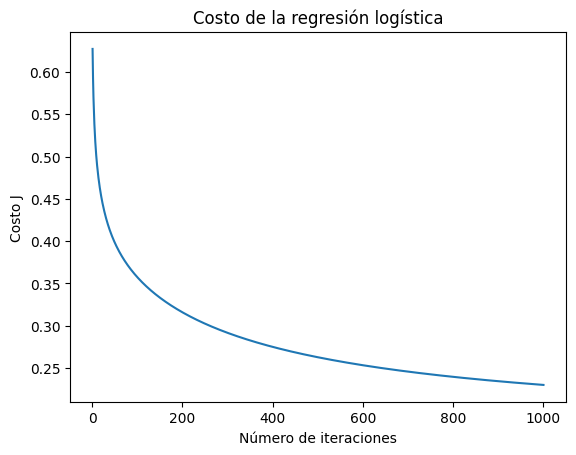

In [ ]:
alpha = 0.5
num_iters = 1000

theta = torch.zeros(X_ready.shape[1], dtype=torch.float64)
theta, J_history = descensoGradiente(theta, X_ready, y_train, alpha, num_iters)

pyplot.plot(range(1, num_iters + 1), J_history)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Costo de la regresión logística')
pyplot.show()

print('Theta calculado por el descenso por el gradiente:')
print(theta)
print('Costo final:', J_history[-1])

## 7. Prueba del modelo
Normalizamos el 20 % reservado para prueba con la misma media y desviación del entrenamiento y añadimos la columna de unos.

In [ ]:
X_test_norm = (X_test - mu) / sigma
m_test = X_test.shape[0]
X_test_ready = torch.cat([
    torch.ones((m_test, 1), dtype=torch.float64), X_test_norm
], dim=1)
print('Tamaño de X_test_ready:', X_test_ready.shape)

Tamaño de X_test_ready: torch.Size([4166, 11])


Calculamos las probabilidades. Si la probabilidad es mayor o igual a **0,5**, la clase predicha es **1**; si es menor, es **0**.

In [ ]:
y_predicha = sigmoid(X_test_ready @ theta)
y_umbral = (y_predicha >= 0.5).to(torch.int64)

### Tabla de resultados
Mostramos las primeras 200 filas de prueba con la clase real, la probabilidad, la clase predicha y las características del jugador. En las clases, 0 significa ocasional y 1 frecuente.

In [ ]:
df_pred = pd.DataFrame({
    'Clase real': y_test.to(torch.int64).numpy(),
    'Probabilidad de jugador frecuente (%)': y_predicha.numpy() * 100,
    'Clase predicha': y_umbral.numpy()
})
X_test_df = pd.DataFrame(X_test.numpy(), columns=variables_predictoras)
df_resultado = pd.concat([df_pred, X_test_df], axis=1)

with pd.option_context('display.max_rows', 200, 'display.max_columns', None):
    display(df_resultado.head(200).round(2))

,Clase real,Probabilidad de jugador frecuente (%),Clase predicha,Total_Shots,Total_Kills,Overall_Accuracy,Melee_Kills,Ranged_Kills,Explosive_Kills,Weapon_Diversity,Most_Friendly_Fire,Average_Friendly_Fire,Difficulty_Ordinal
0,1,100.00,1,2237213.0,720787.0,0.32,166492.0,504577.0,51896.0,27.0,7868.0,43.0,3.0
1,0,0.22,0,355.0,86.0,0.24,0.0,80.0,6.0,3.0,29.0,29.0,1.0
2,1,91.20,1,80737.0,33555.0,0.42,3264.0,24809.0,5570.0,26.0,611.0,43.0,2.0
3,0,24.77,0,23717.0,7513.0,0.32,1766.0,5245.0,536.0,33.0,553.0,69.0,2.0
4,1,82.02,1,78307.0,26812.0,0.34,1019.0,23742.0,2146.0,27.0,1951.0,167.0,3.0
5,0,11.91,0,24168.0,8153.0,0.34,1123.0,5966.0,1145.0,25.0,1357.0,137.0,3.0
6,1,97.80,1,99348.0,38864.0,0.39,8331.0,27547.0,3074.0,26.0,296.0,56.0,1.0
7,0,0.57,0,1218.0,308.0,0.25,8.0,273.0,27.0,10.0,138.0,34.0,2.0
8,1,95.89,1,92393.0,30844.0,0.33,4908.0,23846.0,2168.0,29.0,1371.0,62.0,3.0
9,1,91.77,1,89966.0,24870.0,0.28,3185.0,19327.0,2487.0,27.0,6152.0,219.0,3.0


## 8. Exactitud del modelo en prueba
Es el porcentaje de jugadores de prueba cuya clase predicha coincide con la real.
En el ejemplo aparece rotulada como «precisión de entrenamiento», pero el cálculo utiliza los datos de prueba; aquí se nombra según los datos evaluados.

In [ ]:
exactitud = (y_umbral == y_test).to(torch.float64).mean() * 100
print(f'Exactitud en prueba: {exactitud.item():.2f} %')

Exactitud en prueba: 91.69 %
